In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os, sys
import pandas as pd
import matplotlib.pyplot as plt

path_dat = "D:\data\Full_Model_Outputs.hdf5"
path_mod = os.path.normpath(os.getcwd()+'/../ml_fw/') # assumes current working directory is the ml_fw/Notebooks directory

# add the ml_fw module to Python Path and import what we need
sys.path.append(os.path.dirname(path_mod))

import ml_fw.inspect as inspect

In [3]:
# load the data set and calculate the residuals
dat = pd.read_hdf(path_dat)
dat.head()

,SYM_H_mean,AL_mean_2_delay,AL_mean_3_delay,AL_mean_4_delay,Vx_mean_6_delay,SYM_H_mean_7_delay,Vx_median_1_delay,AL_median_5_delay,Bz_median_7_delay,True Class,Prediction
0,-12.541667,-164.916667,-118.954861,-73.027778,-474.010588,-17.434028,-429.150009,-132.0,-0.555,0,1
1,-11.201389,-39.336806,-35.295139,-37.621528,-538.570137,-9.600694,-318.638370,-60.5,-0.715,0,0
2,5.413194,-46.215278,-73.534722,-76.583333,-366.968228,1.135417,-371.650009,-110.0,-0.320,0,0
3,-2.277778,-15.059028,-12.163194,-27.850694,-548.674652,-7.260417,-333.200012,-30.0,-0.310,0,0
4,-12.347222,-95.906250,-32.118056,-41.416667,-499.194618,-26.777778,-458.850006,-83.0,-0.745,0,0


In [4]:
y_t = 'True Class'
y_p = 'Prediction'
on = 'index'
rkwargs = {'window':11,'center':True}

In [5]:
r_met = inspect.rolling_met(dat,y_true=y_t,y_pred=y_p,on=on,
                        roll_kwargs=rkwargs)

Using Accuracy Metric


<AxesSubplot:ylabel='SYM_H_mean'>

<AxesSubplot:ylabel='AL_median_5_delay'>

<AxesSubplot:ylabel='Running Accuracy'>

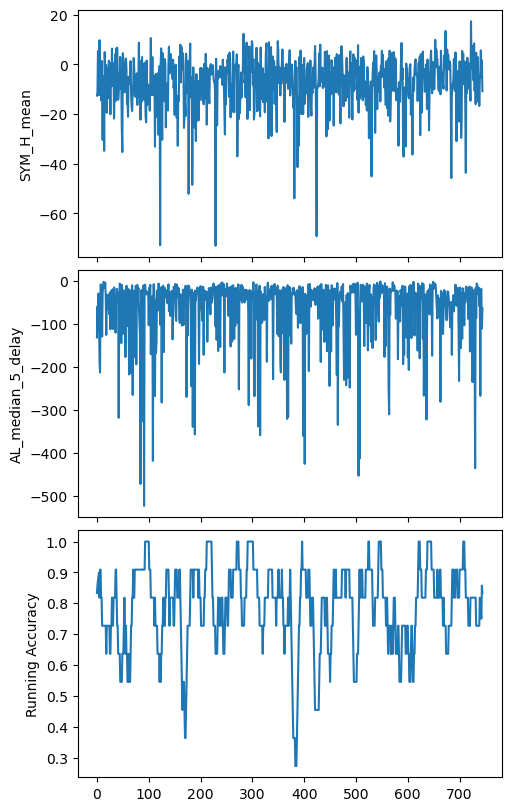

In [15]:
fig1, ax1 = plt.subplots(3,1,figsize=(5,8),sharex=True, layout='constrained')

dat['SYM_H_mean'].plot(ax=ax1[0], ylabel='SYM_H_mean')
dat['AL_median_5_delay'].plot(ax=ax1[1], ylabel='AL_median_5_delay')
r_met['Accuracy'].plot(ax=ax1[2], ylabel='Running Accuracy')